In [283]:
#pip install torch

In [284]:
import numpy as np 
import pandas as pd 
import torch
import math 

import torch.nn as nn 
import torch.optim as optim
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

In [285]:
df = pd.read_csv("D:/Code/Machine-Learning/Data/MLP/[Data]_Ex1_Auto_MPG_data.csv")

print(df.shape)
print(df.info())

(392, 10)
<class 'pandas.DataFrame'>
RangeIndex: 392 entries, 0 to 391
Data columns (total 10 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   MPG           392 non-null    float64
 1   Cylinders     392 non-null    int64  
 2   Displacement  392 non-null    float64
 3   Horsepower    392 non-null    float64
 4   Weight        392 non-null    float64
 5   Acceleration  392 non-null    float64
 6   Model Year    392 non-null    int64  
 7   Europe        392 non-null    int64  
 8   Japan         392 non-null    int64  
 9   USA           392 non-null    int64  
dtypes: float64(5), int64(5)
memory usage: 30.8 KB
None


In [286]:
X = df.drop(columns="MPG").values
y = df["MPG"].values

print(X.shape)
print(y.shape)

print(y[:5])

(392, 9)
(392,)
[18. 15. 18. 16. 17.]


In [287]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(X_train.shape, X_test.shape)
print(y_train.shape, y_test.shape)
print(y)

(313, 9) (79, 9)
(313,) (79,)
[18.  15.  18.  16.  17.  15.  14.  14.  14.  15.  15.  14.  15.  14.
 24.  22.  18.  21.  27.  26.  25.  24.  25.  26.  21.  10.  10.  11.
  9.  27.  28.  25.  19.  16.  17.  19.  18.  14.  14.  14.  14.  12.
 13.  13.  18.  22.  19.  18.  23.  28.  30.  30.  31.  35.  27.  26.
 24.  25.  23.  20.  21.  13.  14.  15.  14.  17.  11.  13.  12.  13.
 19.  15.  13.  13.  14.  18.  22.  21.  26.  22.  28.  23.  28.  27.
 13.  14.  13.  14.  15.  12.  13.  13.  14.  13.  12.  13.  18.  16.
 18.  18.  23.  26.  11.  12.  13.  12.  18.  20.  21.  22.  18.  19.
 21.  26.  15.  16.  29.  24.  20.  19.  15.  24.  20.  11.  20.  19.
 15.  31.  26.  32.  25.  16.  16.  18.  16.  13.  14.  14.  14.  29.
 26.  26.  31.  32.  28.  24.  26.  24.  26.  31.  19.  18.  15.  15.
 16.  15.  16.  14.  17.  16.  15.  18.  21.  20.  13.  29.  23.  20.
 23.  24.  25.  24.  18.  29.  19.  23.  23.  22.  25.  33.  28.  25.
 25.  26.  27.  17.5 16.  15.5 14.5 22.  22.  24.  22.5 29. 

In [288]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print(X_train[:5])
print(X_test[:5])

[[ 0.30486156  0.28457757  0.14142863  0.75480297  1.1217589   0.49452752
  -0.42559614 -0.50199602  0.74128601]
 [-0.87318372 -0.53588042 -0.32949862 -0.49312922 -0.22893966 -0.0572982
  -0.42559614 -0.50199602  0.74128601]
 [ 0.30486156 -0.23665456 -0.19868549 -0.00252992 -0.37111846 -0.33321105
  -0.42559614 -0.50199602  0.74128601]
 [ 1.48290683  1.18225513  1.18793363  1.3680521  -0.72656545 -1.16094962
  -0.42559614 -0.50199602  0.74128601]
 [-0.87318372 -1.05711255 -1.06205212 -1.32309939  0.30423083  1.32226608
  -0.42559614 -0.50199602  0.74128601]]
[[-0.87318372 -0.96058808 -0.931239   -0.94919604  0.87294601 -1.16094962
   2.34964536 -0.50199602 -1.34900698]
 [-0.87318372 -0.71927691  0.27224176 -0.2275864   0.05541793  0.49452752
   2.34964536 -0.50199602 -1.34900698]
 [-0.87318372 -1.00885031 -1.16670262 -1.41240751  0.30423083  0.49452752
  -0.42559614  1.99204768 -1.34900698]
 [-0.87318372 -1.00885031 -0.90507637 -1.22783739  1.76156349 -1.43686248
  -0.42559614 -0.50199

In [289]:
X_train = torch.tensor(X_train, dtype=torch.float32)
X_test = torch.tensor(X_test, dtype=torch.float32)
y_train = torch.tensor(y_train, dtype=torch.float32)
y_test = torch.tensor(y_test, dtype=torch.float32)

y_test = y_test.unsqueeze(dim=-1)
y_train = y_train.unsqueeze(dim=-1)

In [290]:
class MLP(nn.Module):
    def __init__(self):
        super(MLP, self).__init__()
        self.model = nn.Sequential(
            nn.Linear(9, 64),
            nn.ReLU(),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Linear(32, 1)
        )
    def forward(self, x):
        return self.model(x)

In [291]:
model = MLP()

criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

epochs = 1000
for epoch in range(epochs):
    optimizer.zero_grad()
    outputs = model(X_train)
    loss = criterion(outputs, y_train)
    loss.backward()
    optimizer.step()
    
    # if (epoch % 10 == 0):
    #     print(f"epoch: {epoch}, loss: {loss}")
    
model.eval()
with torch.no_grad():
    y_pred= model(X_test)
y_pred = y_pred.numpy()
y_true = y_test.numpy()

mse = mean_squared_error(y_true, y_pred)
rmse = mean_squared_error(y_true, y_pred) ** 0.5
mae = mean_absolute_error(y_true, y_pred)
r2 = r2_score(y_true, y_pred)

print("MSE: ", mse)
print("RMSE: ", rmse)
print("MAE: ", mae)
print("R2_score: ", r2)

MSE:  6.108774662017822
RMSE:  2.471593547090181
MAE:  1.7866214513778687
R2_score:  0.8803153038024902


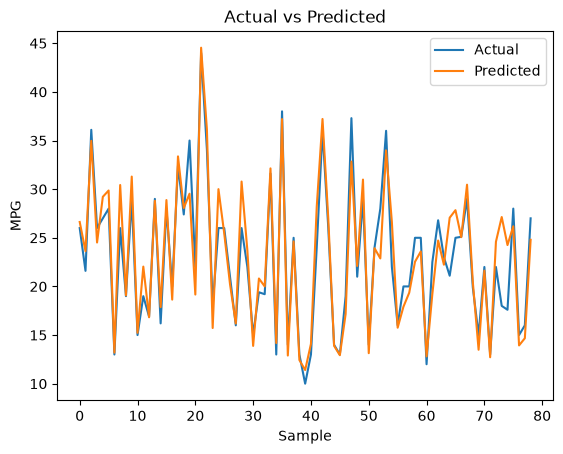

In [292]:
plt.plot(y_true, label="Actual")
plt.plot(y_pred, label="Predicted")

plt.xlabel("Sample")
plt.ylabel("MPG")
plt.title("Actual vs Predicted")

plt.legend()
plt.show()

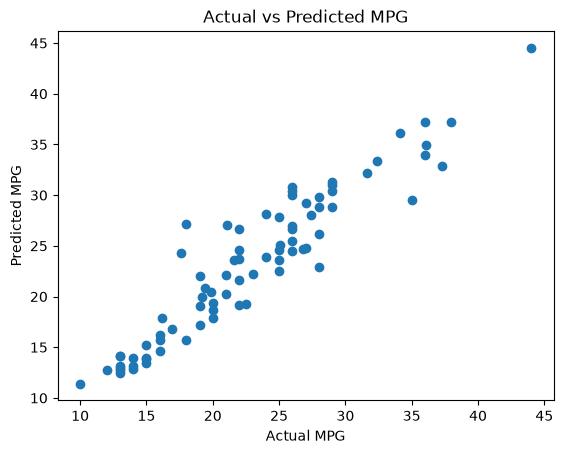

In [293]:
plt.scatter(y_true, y_pred)

plt.xlabel("Actual MPG")
plt.ylabel("Predicted MPG")
plt.title("Actual vs Predicted MPG")

plt.show()